# Exploratory Data Analysis & Multi-Seed Split Verification
**Challenge:** Foundation-Model Fusion in Lung Cancer Subtyping  
**Goal:** Inspect demographic patterns, evaluate class balance, and verify zero data leakage across splits for multiple random seeds (42, 1337, 2026).

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure clean aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Curated Cohort Metadata

In [2]:
curated_path = "../artifacts/curated_patients.csv"
if not os.path.exists(curated_path):
    curated_path = "artifacts/curated_patients.csv"

df_curated = pd.read_csv(curated_path)
print(f"Total Curated Patients: {len(df_curated)}")
display(df_curated.head())

Total Curated Patients: 204


,patient_id,SampleNumber,WSI_ID,Tumor Subtype,Age,Sex,total_patient_slides,available_patient_slides
0,8373873_48_Female,8373873,WSI-1,In situ,48,Female,2,2
1,8340298_51_Male,8340298,WSI-3,In situ,51,Male,2,1
2,8374273_53_Female,8374273,WSI-5,In situ,53,Female,2,2
3,8328230_46_Female,8328230,WSI-7,In situ,46,Female,2,2
4,8365118_30_Female,8365118,WSI-9,In situ,30,Female,2,2


## 2. Demographic Analysis (Age & Sex vs Tumor Subtype)

/tmp/ipykernel_131566/2874150038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_curated, x="Tumor Subtype", y="Age", order=order, palette="Blues_r", ax=axes[0])
/tmp/ipykernel_131566/2874150038.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")


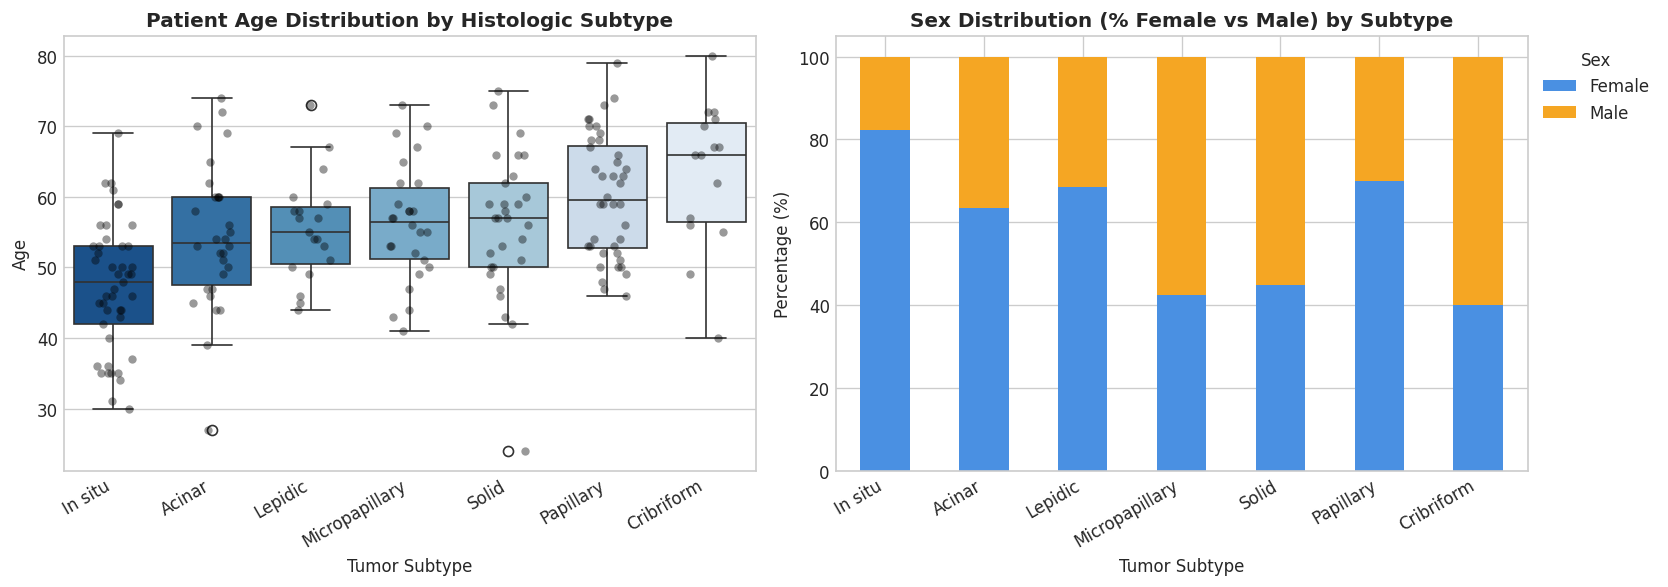

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Boxplot by Subtype
order = df_curated.groupby("Tumor Subtype")["Age"].median().sort_values().index
sns.boxplot(data=df_curated, x="Tumor Subtype", y="Age", order=order, palette="Blues_r", ax=axes[0])
sns.stripplot(data=df_curated, x="Tumor Subtype", y="Age", order=order, color="black", alpha=0.4, jitter=0.2, ax=axes[0])
axes[0].set_title("Patient Age Distribution by Histologic Subtype", fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

# Sex Proportion by Subtype
sex_cross = pd.crosstab(df_curated["Tumor Subtype"], df_curated["Sex"], normalize="index") * 100
sex_cross.loc[order].plot(kind="bar", stacked=True, color=["#4A90E2", "#F5A623"], ax=axes[1])
axes[1].set_title("Sex Distribution (% Female vs Male) by Subtype", fontweight="bold")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].legend(title="Sex", loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## 3. Multi-Seed Split Verification & Class Balance

In [4]:
seeds = [42, 1337, 2026]
split_dfs = {}
splits_dir = "../artifacts/splits" if os.path.exists("../artifacts/splits") else "artifacts/splits"

for seed in seeds:
    path = os.path.join(splits_dir, f"splits_seed_{seed}.csv")
    df_s = pd.read_csv(path)
    split_dfs[seed] = df_s
    print(f"Seed {seed}: Total={len(df_s)} | Train={sum(df_s.split=='train')} | Val={sum(df_s.split=='val')} | Test={sum(df_s.split=='test')}")

# Verify zero leakage across all seeds
for seed, df_s in split_dfs.items():
    train_p = set(df_s[df_s.split == 'train'].patient_id)
    val_p = set(df_s[df_s.split == 'val'].patient_id)
    test_p = set(df_s[df_s.split == 'test'].patient_id)
    assert len(train_p & val_p) == 0, f"Leakage in Seed {seed} (train-val)"
    assert len(train_p & test_p) == 0, f"Leakage in Seed {seed} (train-test)"
    assert len(val_p & test_p) == 0, f"Leakage in Seed {seed} (val-test)"
print("[PASSED] Zero patient leakage verified across all seeds!")

Seed 42: Total=204 | Train=142 | Val=21 | Test=41
Seed 1337: Total=204 | Train=142 | Val=21 | Test=41
Seed 2026: Total=204 | Train=142 | Val=21 | Test=41
[PASSED] Zero patient leakage verified across all seeds!


## 4. Visualizing Subtype Counts across Train, Val, and Test per Seed

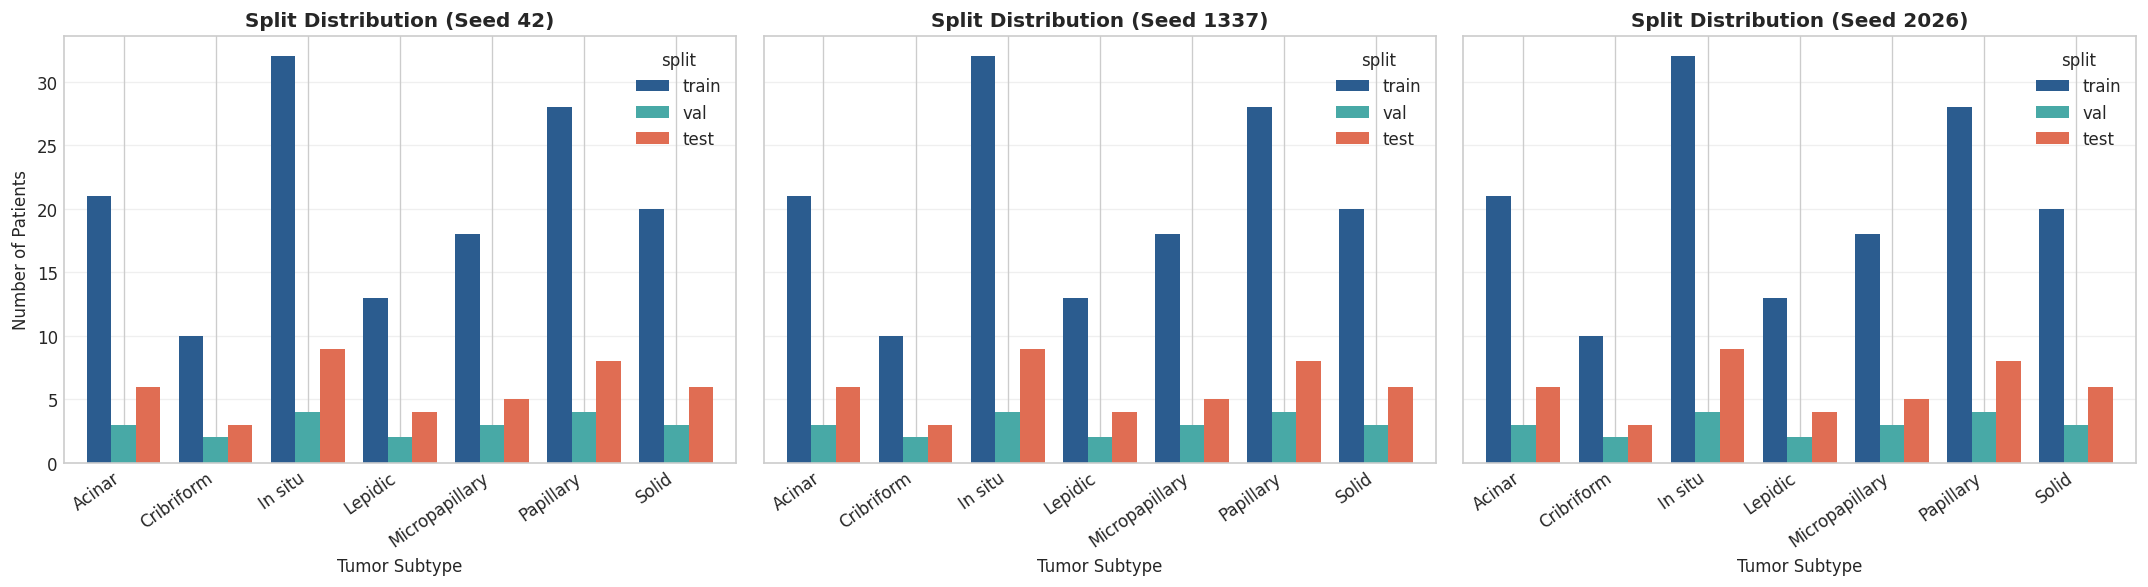

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, seed in enumerate(seeds):
    df_s = split_dfs[seed]
    ct = pd.crosstab(df_s["Tumor Subtype"], df_s["split"])[["train", "val", "test"]]
    ct.plot(kind="bar", ax=axes[i], color=["#2b5c8f", "#48a9a6", "#e06d53"], width=0.8)
    axes[i].set_title(f"Split Distribution (Seed {seed})", fontweight="bold")
    axes[i].set_xlabel("Tumor Subtype")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=35, ha="right")
    if i == 0:
        axes[i].set_ylabel("Number of Patients")
    axes[i].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Summary Findings
1. **Strict Patient-Level Partition**: Guaranteed 0 patient leakage between train, validation, and test across all seeds.
2. **Rare Subtype Representation**: Every split retains non-zero representation of Cribriform (n=15), Micropapillary (n=26), and Lepidic (n=21).
3. **Demographic Signal**: Subtype is strongly correlated with Age and Sex (e.g. In situ has median age < 50 and >80% female), confirming their importance as multimodal features in downstream fusion.